### Import library

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, accuracy_score, f1_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import RandomizedSearchCV

numpy, pandas = manipulasi data

matplotlib, seaborn = visualisasi grafik

RandomForestClassifier = model klasifikasi yang digunakan

StandardScaler = normalisasi fitur numerik

train_test_split = pembagian data train & test

metrics = evaluasi performa model

PartialDependenceDisplay = interpretasi model (PDP)

#### Load Data Set

In [107]:

df = pd.read_csv("smoking_health_data_final.csv")
df.info()
display(df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             3900 non-null   int64  
 1   sex             3900 non-null   object 
 2   current_smoker  3900 non-null   object 
 3   heart_rate      3900 non-null   int64  
 4   blood_pressure  3900 non-null   object 
 5   cigs_per_day    3886 non-null   float64
 6   chol            3893 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 213.4+ KB


,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
2243,48,female,yes,67,135/82.5,5.0,192.0
2744,44,male,yes,75,150/95,15.0,274.0
46,60,female,no,82,114/64,0.0,391.0
1915,54,female,no,78,110/67.5,0.0,223.0
2110,45,female,yes,65,133.5/85.5,3.0,220.0


load data sekaligus menampilkan tipe data lima data secara random

### Data preparation

##### 1. Mengisi missing Valaue

In [108]:
# isi missing pada cigs_per_day dan chol dengan median (sama seperti di prakds.py)
if 'cigs_per_day' in df.columns:
    df['cigs_per_day'] = df['cigs_per_day'].fillna(df['cigs_per_day'].median())
if 'chol' in df.columns:
    df['chol'] = df['chol'].fillna(df['chol'].median())


mengisi missing value dengga menggunakan median karena tidak terlalu tertarik dengan nilai ekstreme. Hal ini menjadi pertimbangan karena dalam data tersebut juga terdapat orang yang tidak merokok dan kolestrol yang sangat tinggi. Apabila menggunakan mean nanti hasil akan tertarik pada nilai tersebut yang akan mengganggun kesemimbangan data

#### 2. Memisahkan 'blood_pressure' menjadi sistolik dan diastolik

In [109]:
# split blood_pressure -> systolic/diastolic kalau ada
if 'blood_pressure' in df.columns and 'systolic' not in df.columns:
    df[['systolic', 'diastolic']] = df['blood_pressure'].str.split('/', expand=True)
    df = df.drop(columns=['blood_pressure'])

pada tekanan darah tertera '..../....' yang akan sulit diperoses dan pada penerapan dunia nyata bagian bagian tersebut dinamai sistolik dan diastolik

#### 3. Memberishkan white space

In [110]:
# bersihkan whitespace dan cast numeric
for col in ['systolic', 'diastolic']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

Bagian ini membersihkan kolom tekanan darah systolic dan diastolic. Pertama, semua nilai diubah ke string dan di-trim untuk menghilangkan spasi tersembunyi yang dapat menyebabkan error. Setelah itu, nilainya dikonversi menjadi numerik. Jika ada nilai tidak valid seperti huruf atau simbol, kita terjemahkan menjadi NaN menggunakan errors='coerce'. Langkah ini memastikan data siap diproses dengan model machine learning.

#### 4. Encoding kategori: sex & current_smoker

In [111]:
# map kategorikal sex & current_smoker ke 0/1 bila belum
if 'sex' in df.columns and df['sex'].dtype == object:
    df['sex'] = df['sex'].map({'female':0, 'male':1}).fillna(df['sex'])
if 'current_smoker' in df.columns and df['current_smoker'].dtype == object:
    df['current_smoker'] = df['current_smoker'].map({'no':0, 'yes':1}).fillna(df['current_smoker'])

memisahkan data yang bersifat kategorikal menjadi 0/1 agar mudah dalam diperoses

#### 5. Membuang outlier kolestrol

In [112]:
# filter out extreme chol like di skrip original
if 'chol' in df.columns:
    data_normal = df[df['chol'] < 400].copy()
else:
    data_normal = df.copy()

bertujuan untuk membersihkan data kolestrol dari nilai ekstrem sebelum dipakai

#### 6. Membuat label high_bp

In [113]:
# buat label high_bp jika ada systolic/diastolic
if ('systolic' in data_normal.columns) and ('diastolic' in data_normal.columns):
    data_normal['high_bp'] = (
        (data_normal['systolic'] >= 140) |
        (data_normal['diastolic'] >= 90)
    ).astype(int)
else:
    raise RuntimeError("Butuh kolom 'systolic' dan 'diastolic' untuk membuat label high_bp.")

display(data_normal.sample(5))
data_normal.info()

,age,sex,current_smoker,heart_rate,cigs_per_day,chol,systolic,diastolic,high_bp
806,52,0,0,90,0.0,245.0,145.0,89.0,1
3760,48,1,1,60,40.0,226.0,117.5,80.0,0
702,50,0,0,74,0.0,225.0,132.0,81.0,0
1723,55,0,0,75,0.0,340.0,140.0,83.0,1
2889,49,1,1,75,20.0,247.0,150.0,88.0,1


<class 'pandas.core.frame.DataFrame'>
Index: 3890 entries, 0 to 3899
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             3890 non-null   int64  
 1   sex             3890 non-null   int64  
 2   current_smoker  3890 non-null   int64  
 3   heart_rate      3890 non-null   int64  
 4   cigs_per_day    3890 non-null   float64
 5   chol            3890 non-null   float64
 6   systolic        3890 non-null   float64
 7   diastolic       3890 non-null   float64
 8   high_bp         3890 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 303.9 KB


melabeli seseorang mengalami darah tinggi atau tidak dengan parameter orang yang memiliki tekanan darah diatas 140 untuk sistolik dan diatas 90 untuk diastolik

#### 7. Cek imbalance data

In [114]:
data_normal['high_bp'].value_counts()

,count
high_bp,
0,2497
1,1393


In [115]:
data_normal['high_bp'].value_counts(normalize=True) * 100

,proportion
high_bp,
0,64.190231
1,35.809769


Dari pengecekan imbalance data didapatkan hasil:  
- Tidak hipertensi (0): 64.2%  
- Hipertensi (1): 35.8%  

Data ini tidak mengalami imbalance yang parah yang dimana untuk perbandingan kelas balance adalah 50:50 - 60-40, untuk perbandingan yang sedikit imbalance adalah 70:30. Jadi tidak perlu melakukan penanganan imbalance data

### Modeling

#### 1. Split fitur dan target

In [116]:
# fitur dan target
X = data_normal.drop(['systolic', 'diastolic', 'high_bp'], axis=1)
y = data_normal['high_bp']

membafi dataset menjadi fitur x dan y

x = digunakan sebagai input untuk melakuakan prediksi

y = kolom target, sesuatu yang ingin diprediksi oleh model

#### 2. Menghapus fitur non-numerik jika masih ada

In [117]:
# Hapus kolom non-numeric unexpected, atau encode jika perlu
# (pastikan semua kolom X numeric; untuk simplicity, drop yang non-numeric)
non_numeric = X.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print("Warning: found non-numeric cols, they will be dropped:", non_numeric)
    X = X.drop(columns=non_numeric)

Bagian kode ini digunakan untuk memastikan bahwa semua kolom fitur (X) sudah berupa angka, karena model machine learning seperti Random Forest tidak bisa memproses teks secara langsung.

#### 3. Train test split

In [118]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

Baris ini digunakan untuk membagi dataset menjadi data pelatihan (training) dan data pengujian (testing) sebelum model Random Forest dilatih.

#### 4. scaling normalisasi

In [119]:
# scaling numeric (jangan scale sex/current_smoker)
to_scale = [c for c in X_train.columns if c not in ['sex', 'current_smoker']]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
if to_scale:
    X_train_scaled[to_scale] = scaler.fit_transform(X_train[to_scale])
    X_test_scaled[to_scale] = scaler.transform(X_test[to_scale])

Bagian kode ini melakukan proses scaling pada fitur-fitur numerik agar seluruh variabel memiliki skala yang sebanding sebelum digunakan oleh model. Fitur biner seperti sex dan current_smoker tidak di-scale karena nilainya sudah dalam bentuk 0 dan 1. StandardScaler digunakan untuk menormalkan fitur numerik menjadi distribusi dengan rata-rata 0 dan standar deviasi 1. Proses fit_transform hanya dilakukan pada data training agar model tidak “mengintip” informasi dari data testing (mencegah data leakage), sementara data testing hanya di-transform menggunakan parameter scaling yang sama sehingga hasilnya konsisten. Dengan scaling ini, model dapat belajar dari data yang lebih stabil dan terstandarisasi.

#### 5. Training model random forrest

In [120]:
# TRAIN RandomForestClassifier

param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None]
}

In [121]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [122]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,    # 20 kombinasi
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [123]:
random_search.fit(X_train_scaled, y_train)  # Waktu eksekusi sekitar 30 detik

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': ['balanced', None],
                                        'max_depth': [6, 8, 10, 12],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 15],
                                        'n_estimators': [100, 150, 200, 250,
                                                         300]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [124]:
best_rf = random_search.best_estimator_

print("Best Params:")
print(random_search.best_params_)

Best Params:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}


Penggunaan Hyperparameter Tuning dengan RandomizedSearchCV membantu mengurangi overfitting pada model Random Forest dengan mencari kombinasi parameter yang menghasilkan generalisasi terbaik, bukan hanya performa tinggi pada data training. Melalui pencarian acak pada ruang parameter seperti max_depth, min_samples_split, min_samples_leaf, dan max_features, metode ini secara efektif mencegah model membangun pohon yang terlalu dalam atau terlalu kompleks, yang merupakan penyebab utama overfitting. Parameter seperti class_weight dan bootstrap juga ikut berperan dalam menyeimbangkan kontribusi sampel serta meningkatkan keragaman pohon pada ensemble. Selain itu, evaluasi berbasis k-fold cross-validation memastikan bahwa model diuji pada berbagai subset data sehingga parameter yang dipilih benar-benar robust terhadap data baru. Dengan demikian, RandomizedSearchCV menghasilkan model yang lebih stabil, tidak mudah overfit, dan memiliki performa generalisasi yang lebih baik.

In [125]:
# predict
y_test_pred = best_rf.predict(X_test_scaled)
y_test_proba = best_rf.predict_proba(X_test_scaled)[:, 1]  # probabilitas untuk kelas 1

y_train_pred = best_rf.predict(X_train_scaled)
y_train_proba = best_rf.predict_proba(X_train_scaled)[:, 1]

Pada tahap ini, model Random Forest yang sudah dilatih digunakan untuk melakukan prediksi terhadap data testing yang belum pernah dilihat sebelumnya. Perintah rf.predict(X_test_scaled) menghasilkan prediksi kelas pada setiap sampel, yaitu apakah seseorang termasuk kategori high_bp (1) atau tidak (0). Sementara itu, rf.predict_proba(X_test_scaled)[:, 1] memberikan probabilitas bahwa setiap sampel termasuk ke kelas 1, yaitu peluang seseorang memiliki tekanan darah tinggi. Dengan demikian, bagian ini tidak hanya menentukan hasil prediksi kelas, tetapi juga memberikan informasi seberapa yakin model terhadap prediksi tersebut melalui nilai probabilitasnya.

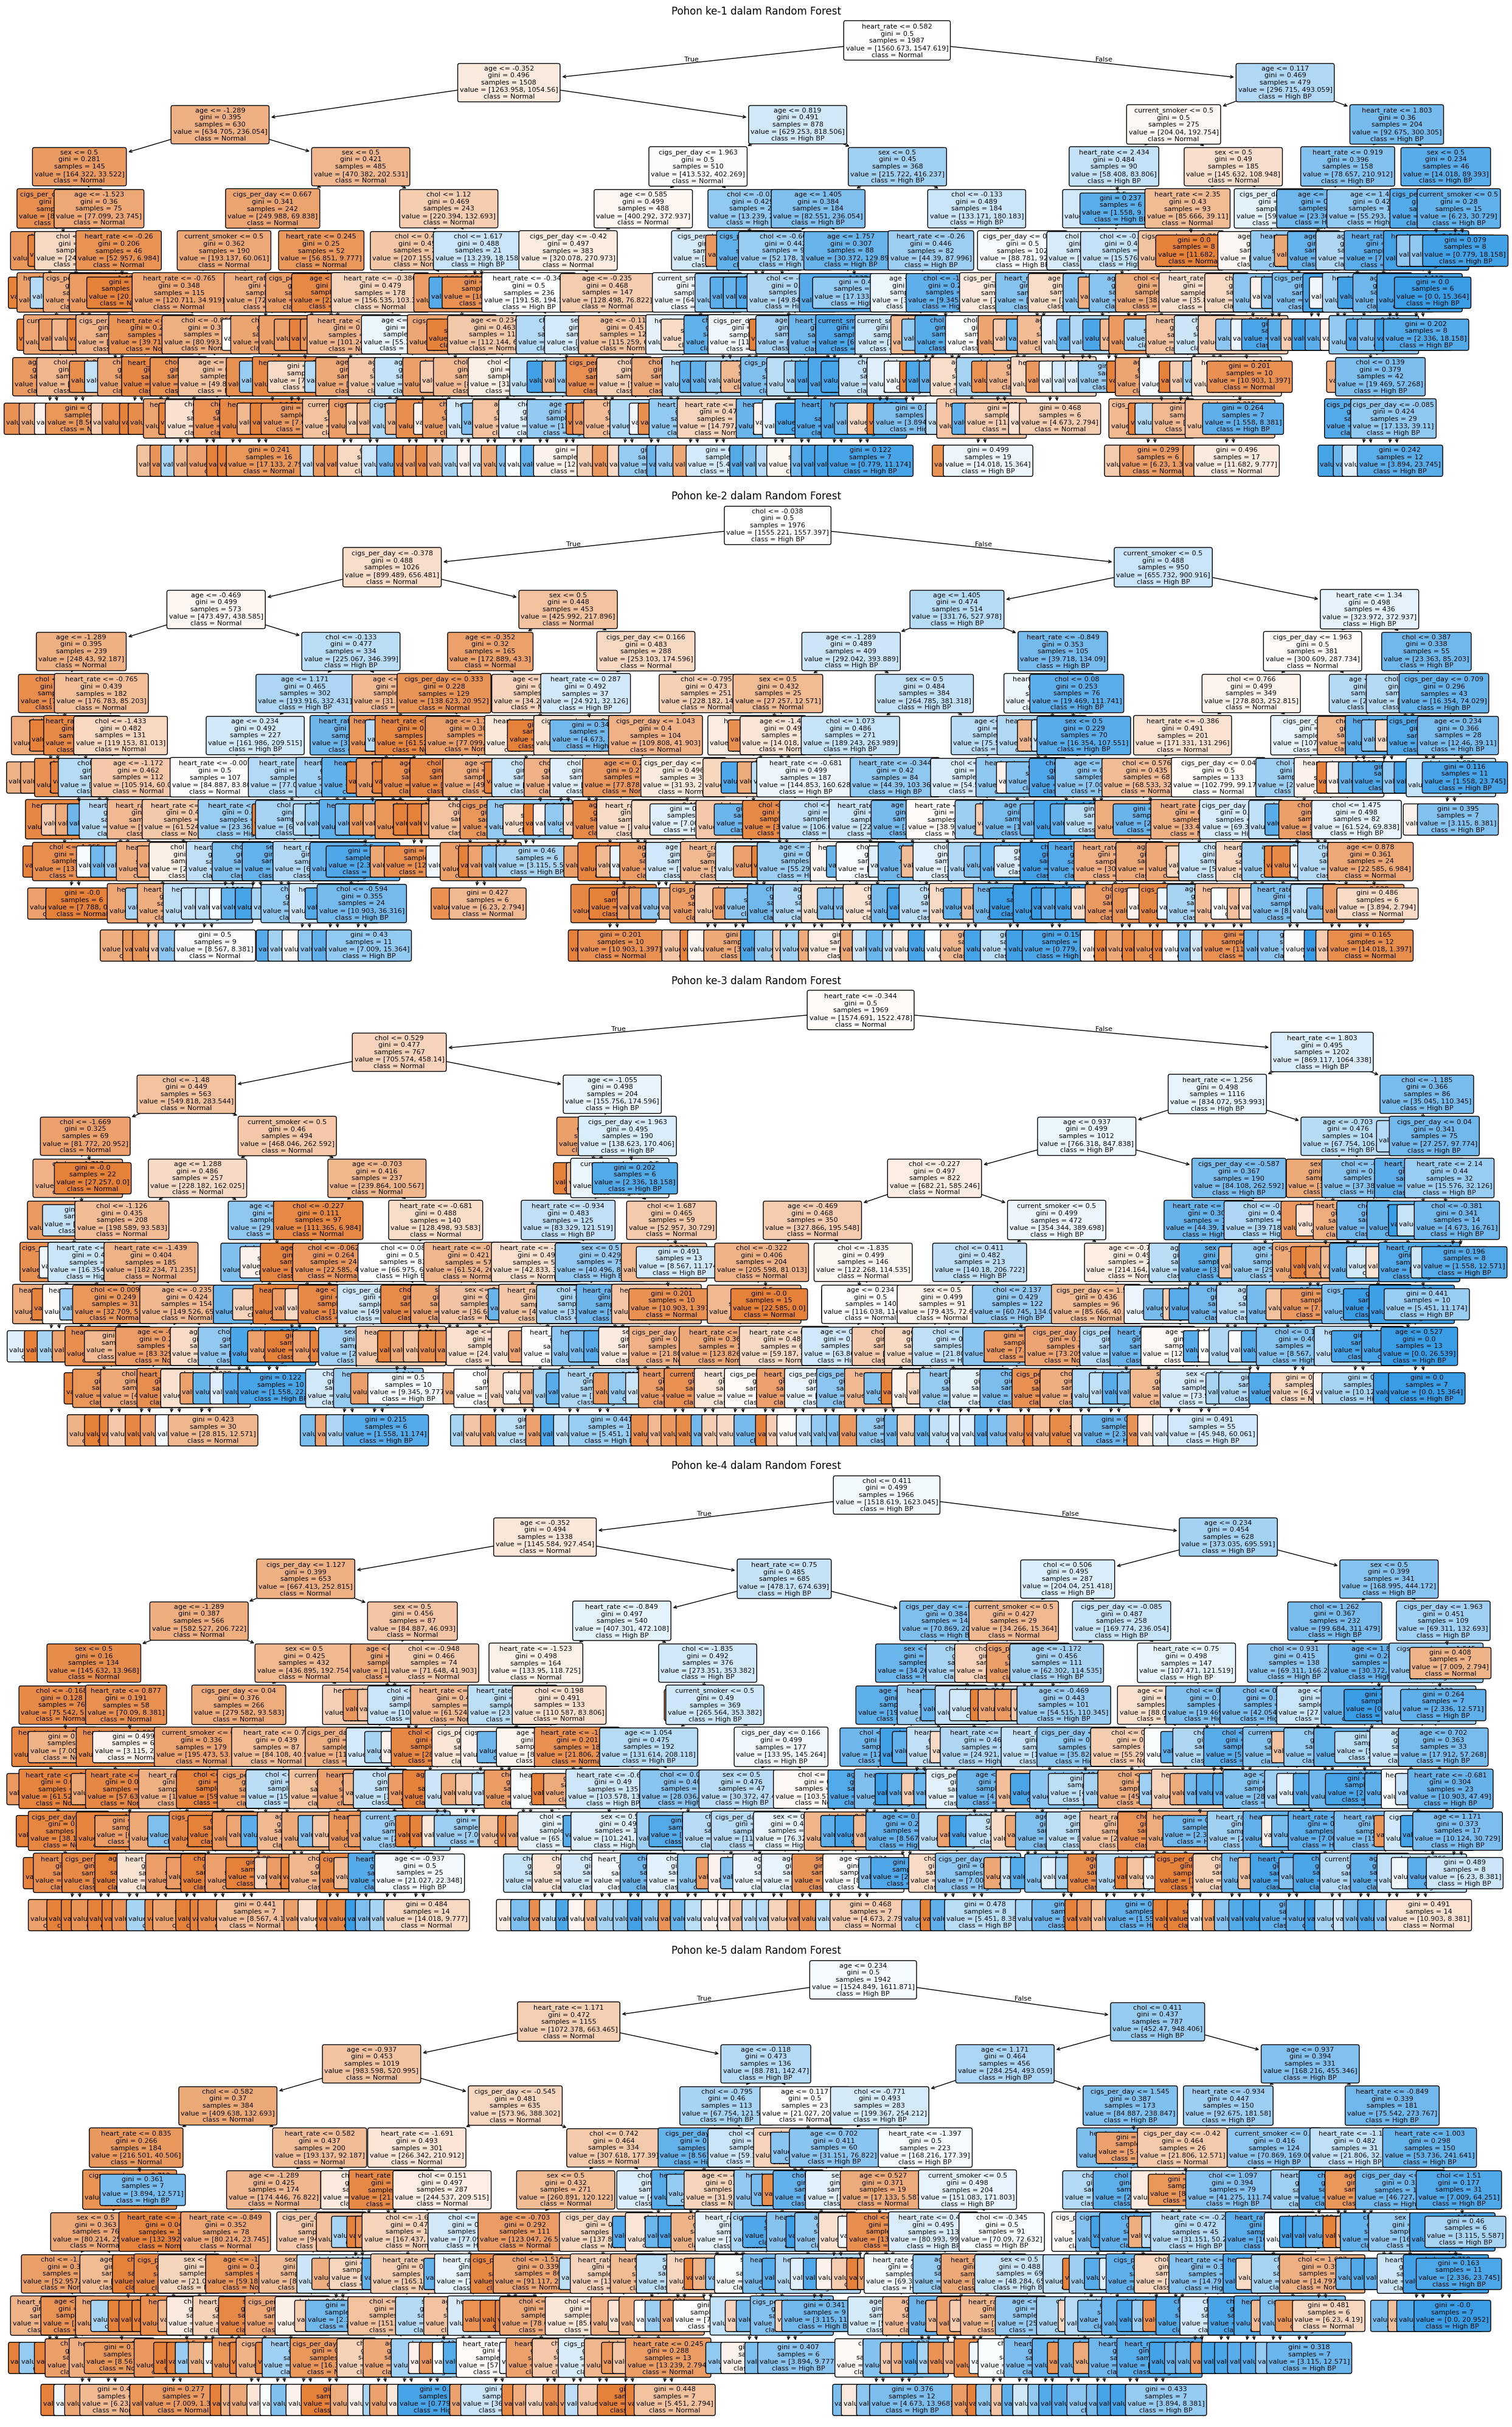

In [126]:
# Visualisasi random forest waktu eksekusi sekitar 1m 5d

n_pohon = 5
estimators = best_rf.estimators_[:n_pohon]
plt.figure(figsize=(25, 40))

for i, estimator in enumerate(estimators):
    plt.subplot(n_pohon, 1, i + 1)

    plot_tree(
        estimator,
        feature_names = X.columns,
        class_names = ['Normal', 'High BP'],
        filled=True,
        rounded=True,
        fontsize=8
    )

    plt.title(f'Pohon ke-{i+1} dalam Random Forest', fontsize=12)

plt.tight_layout()
plt.show()

#### 6. Evaluasi model

In [127]:
print("Train Accuracy :", accuracy_score(y_train, y_train_pred))
print("Test Accuracy  :", accuracy_score(y_test, y_test_pred))
print()

print("Train F1-score :", f1_score(y_train, y_train_pred, average='weighted'))
print("Test F1-score  :", f1_score(y_test, y_test_pred, average='weighted'))
print()

print("CLASSIFICATION REPORT (TRAIN)")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICATION REPORT (TEST)")
print(classification_report(y_test, y_test_pred))

Train Accuracy : 0.7715295629820051
Test Accuracy  : 0.6413881748071979

Train F1-score : 0.7751085475418775
Test F1-score  : 0.6473849991211151

CLASSIFICATION REPORT (TRAIN)
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1998
           1       0.65      0.78      0.71      1114

    accuracy                           0.77      3112
   macro avg       0.76      0.77      0.76      3112
weighted avg       0.79      0.77      0.78      3112

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.75      0.66      0.70       499
           1       0.50      0.61      0.55       279

    accuracy                           0.64       778
   macro avg       0.63      0.63      0.63       778
weighted avg       0.66      0.64      0.65       778



- Sebemlum ditangani Hyperparamater menggunakan RandomizedSearchCV  
Train accuracy: 0.756426735218509  
Test accuracy : 0.6336760925449871  
Train F1-score : 0.6906122448979591  
Test F1-score  : 0.5425361155698234  

- Setelah ditangani Hyperparamater menggunakan RandomizedSearchCV  
Train Accuracy : 0.7715295629820051  
Test Accuracy  : 0.6413881748071979  
Train F1-score : 0.7751085475418775  
Test F1-score  : 0.6473849991211151


Accuracy = proporsi seluruh prediksi yang benar.

Precision = ketepatan prediksi positif.

Recall = kemampuan menemukan kasus positif.

F1-score = kombinasi precision dan recall.

Support = jumlah sampel aktual di tiap kelas.

Macro avg = rata-rata precision/recall/F1 dari semua kelas tanpa mempertimbangkan jumlah sampel.

Weighted avg = rata-rata precision/recall/F1 dari semua kelas dengan mempertimbangkan jumlah sampel (support).

Setelah dilakukan hyperparameter tuning menggunakan RandomizedSearchCV, nilai akurasi dan F1-score pada data training sedikit menurun, namun nilai pada data testing mengalami peningkatan. Hal ini menunjukkan bahwa kompleksitas model berhasil dikurangi sehingga overfitting berkurang. Model menjadi lebih general dan performanya pada data yang belum pernah dilihat meningkat secara konsisten. Dengan demikian, tuning berhasil menyeimbangkan bias–variance trade-off dan menghasilkan model Random Forest yang lebih stabil dan lebih baik dalam generalisasi.

### Visualisasi

#### 1. Confussion matrix

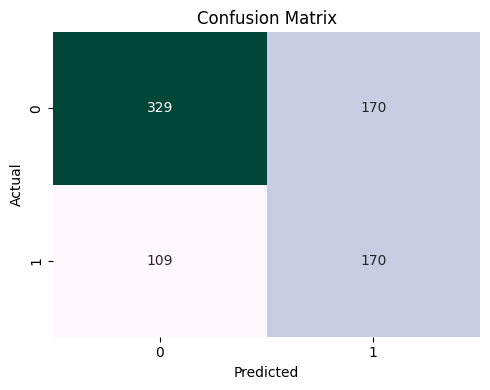

In [128]:
# Confusion matrix (heatmap)

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


Bagian ini digunakan untuk menampilkan confusion matrix, yaitu tabel yang menunjukkan jumlah prediksi benar dan salah pada masing-masing kelas. Confusion matrix membantu melihat secara langsung berapa banyak data high_bp yang berhasil diprediksi dengan benar (true positives), berapa yang terdeteksi normal padahal seharusnya high_bp (false negatives), serta kesalahan prediksi sebaliknya. Kode ini menghitung confusion matrix menggunakan confusion_matrix(), lalu menampilkannya dalam bentuk heatmap agar lebih mudah dibaca. Plot ini juga disimpan sebagai file PNG sehingga dapat digunakan dalam laporan atau presentasi.

#### 2. Feature importance

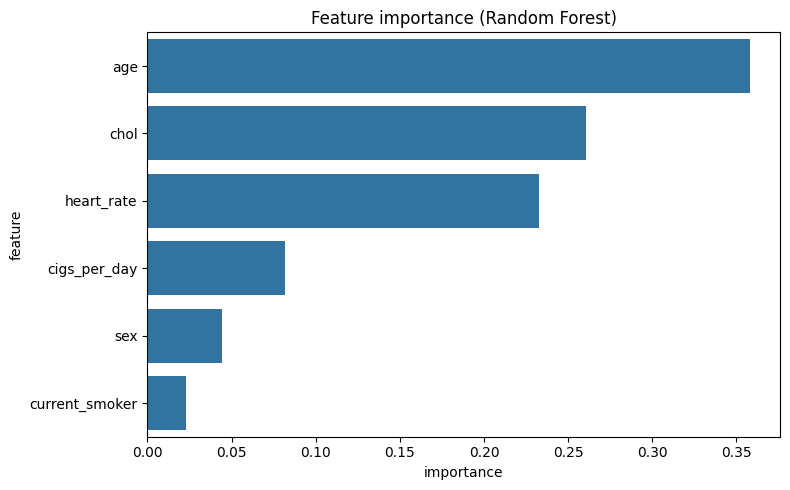

In [129]:
# Feature importance (bar plot)

importances = best_rf.feature_importances_
feat_names = X_train_scaled.columns
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=imp_df, x='importance', y='feature')
plt.title('Feature importance (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

Feature importance memberikan gambaran fitur mana yang paling berpengaruh dan mana yang kurang relevan dalam menentukan output. Visualisasi ini sangat membantu dalam analisis karena memungkinkan kita memahami variabel apa yang benar-benar penting, membantu proses interpretasi model, pemilihan fitur (feature selection), serta mengurangi kompleksitas model dengan menghilangkan fitur yang tidak signifikan. Selain itu, fitur yang memiliki nilai importance tinggi dapat menjadi fokus analisis lanjutan untuk memahami lebih dalam hubungan antar variabel dalam dataset.

#### 3. ROC curve

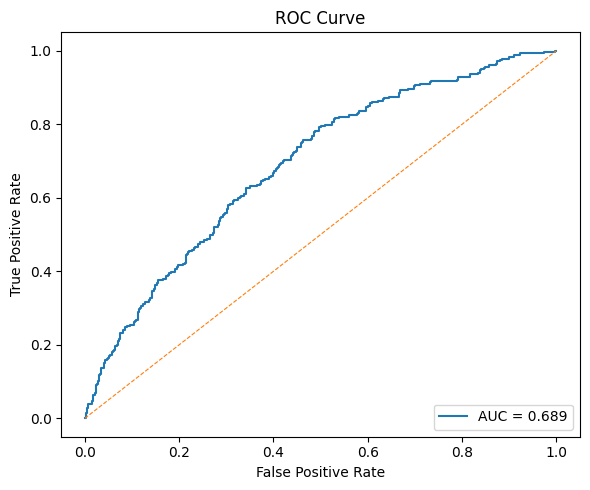

In [130]:
# ROC Curve + AUC

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### 4. Precission recall curve

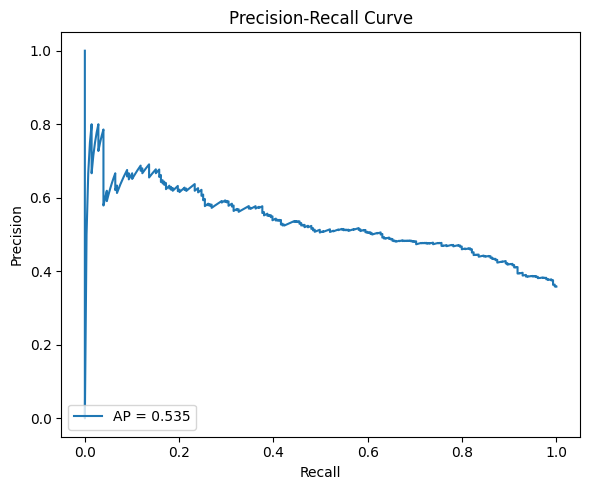

In [131]:
# Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AP = {ap:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

#### 5. Distribusi probabilitas

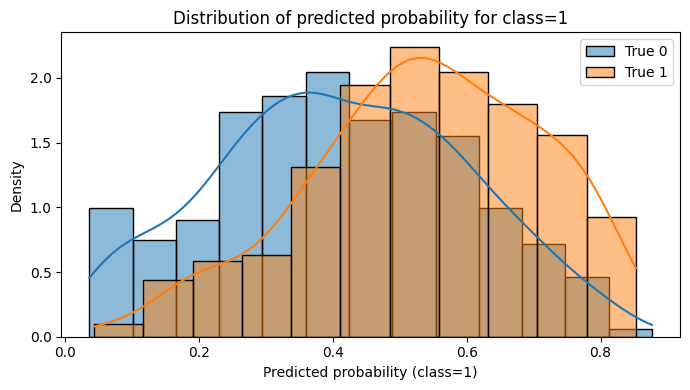

In [132]:
# Distribution of predicted probabilities (by true class)

plt.figure(figsize=(7,4))
sns.histplot(y_test_proba[y_test==0], label='True 0', stat='density', kde=True)
sns.histplot(y_test_proba[y_test==1], label='True 1', stat='density', kde=True)
plt.title('Distribution of predicted probability for class=1')
plt.xlabel('Predicted probability (class=1)')
plt.legend()
plt.tight_layout()
plt.show()

#### 6. Plot dependensi parsial

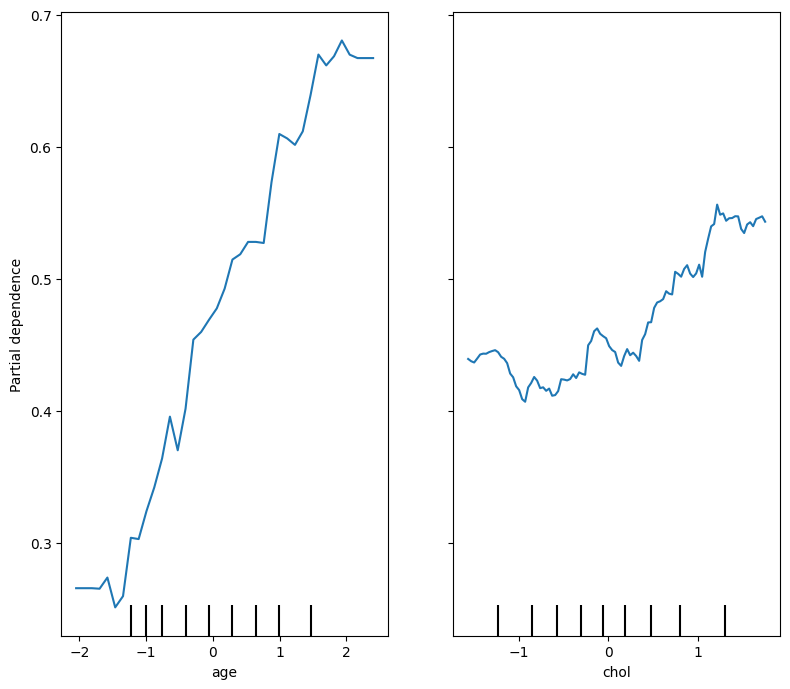

In [133]:
# Partial Dependence (top 2 features)

top_features = imp_df['feature'].tolist()[:2]
if top_features:
    fig, ax = plt.subplots(figsize=(8, 3.5 * len(top_features)))
    PartialDependenceDisplay.from_estimator(best_rf, X_train_scaled, features=top_features, ax=ax)
    plt.tight_layout()
    plt.show()

#### 7. Scatter Plot fitur terpeting

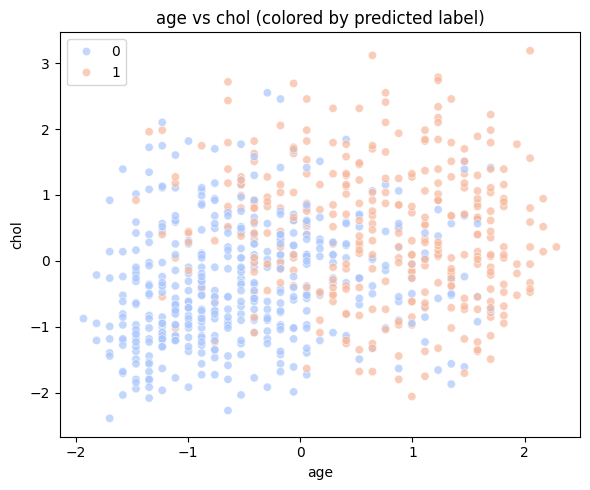

Selesai. Semua gambar disimpan sebagai png pada working directory.


In [134]:
# Scatter of two top features colored by predicted label

if len(top_features) >= 2:
    f1, f2 = top_features[0], top_features[1]
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X_test_scaled[f1], y=X_test_scaled[f2], hue=y_test_pred, palette='coolwarm', alpha=0.7)
    plt.title(f'{f1} vs {f2} (colored by predicted label)')
    plt.tight_layout()
    plt.show()

print("Selesai. Semua gambar disimpan sebagai png pada working directory.")

#### Prediksi

In [135]:
# 1) Masukkan data baru
new_data = pd.DataFrame([{
    'age': 22,
    'sex': 1,             # 1: Male, 0: female
    'heart_rate': 82,
    'chol': 230,
    'cigs_per_day': 10,
    'current_smoker': 1
}])

# 2) Tentukan kolom mana yang di-scale (sama seperti training)
to_scale = [c for c in X_train.columns if c not in ['sex','current_smoker']]

# 3) Scaling numerik
new_data_scaled = new_data.copy()
new_data_scaled[to_scale] = scaler.transform(new_data[to_scale])

# 4) Susun ulang kolom agar URUTANNYA SAMA dengan X_train
new_data_scaled = new_data_scaled[X_train.columns]

# 5) Prediksi
pred_class = best_rf.predict(new_data_scaled)[0]
pred_prob  = best_rf.predict_proba(new_data_scaled)[0][1]

print("Predicted class:", pred_class)
print("Probability high_bp:", pred_prob)


Predicted class: 0
Probability high_bp: 0.2408515902593363
